# Validate Input-Data Stores

This notebook performs a quick visual and statistical sanity check on the unified icechunk
stores produced by the ETL pipelines in `src/srm/input_data/`. Each pipeline ingests raw
GCM/observational output, harmonizes calendars, units, and ensemble-member identifiers, and
writes a single per-source icechunk store consumed by the BCSD pipeline's
`prepare_observations` and `fit_historical` stages.

Sources covered:

| Source | Module | Store |
|---|---|---|
| ERA5 (observations) | `src/srm/input_data/era5.py` | `s3://carbonplan-srm/input/tensor/era5.icechunk` |
| CESM2-WACCM | `src/srm/input_data/cesm2_waccm.py` | `s3://carbonplan-srm/input/tensor/cesm2-waccm.icechunk` |
| MIROC-ES2H | `src/srm/input_data/miroc.py` | `s3://carbonplan-srm/input/tensor/miroc-es2h.icechunk` |

For each source we open the store read-only, inspect its structure, and run a handful of
lightweight checks (spatial maps, ensemble/time coverage, physical-constraint violations).
All checks operate on small slices or single grid points so they can run without a Coiled
cluster — full-array reductions over the multi-hundred-GB variables are deliberately avoided.

In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import qaqc

BUCKET = "carbonplan-srm"


def open_unified_store(prefix: str, bucket: str = BUCKET):
    """Open a unified icechunk store read-only as a DataTree (or Dataset if flat)."""
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    try:
        obj = xr.open_datatree(session.store, engine="zarr", chunks="auto")
    except Exception:
        obj = xr.open_dataset(session.store, engine="zarr", chunks="auto")
    return repo, obj


def summarize_groups(dt: xr.DataTree) -> pd.DataFrame:
    """One row per group/scenario: members, time range, grid shape, variables."""
    rows = []
    for name, node in dt.children.items():
        ds = node.to_dataset()
        rows.append(
            {
                "group": name,
                "ensemble_members": ds.sizes.get("ensemble_member"),
                "n_time": ds.sizes.get("time"),
                "time_start": str(ds.time.values[0])[:10],
                "time_end": str(ds.time.values[-1])[:10],
                "lat x lon": f"{ds.sizes['lat']} x {ds.sizes['lon']}",
                "variables": ", ".join(sorted(ds.data_vars)),
            }
        )
    return pd.DataFrame(rows).set_index("group")


def point_missingness(ds: xr.Dataset, var: str, lat: float = 0.0, lon: float = 0.0) -> xr.DataArray:
    """NaN mask for one variable at a single grid point, for every (ensemble_member, time).

    Cheap proxy for store-wide structural gaps: when a `reindex`-based merge fills missing
    (member, time) combinations with NaN, that NaN pattern is uniform across lat/lon, so a
    single point reproduces the full coverage map at a fraction of the I/O cost.
    """
    point = ds[var].sel(lat=lat, lon=lon, method="nearest")
    return point.isnull().compute()


def plot_missingness(mask: xr.DataArray, title: str, freq: str = "YS"):
    """Heatmap of fraction-missing per ensemble member, resampled along time."""
    frac = mask.resample(time=freq).mean()
    fig, ax = plt.subplots(figsize=(12, 0.6 * frac.sizes["ensemble_member"] + 1.5))
    im = ax.pcolormesh(
        frac.time,
        np.arange(frac.sizes["ensemble_member"]),
        frac.values,
        cmap="Reds",
        vmin=0,
        vmax=1,
    )
    ax.set_yticks(np.arange(frac.sizes["ensemble_member"]))
    ax.set_yticklabels(frac.ensemble_member.values)
    ax.set_xlabel("time")
    ax.set_ylabel("ensemble_member")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="fraction NaN")
    plt.tight_layout()

## 1. ERA5: Observational Reference

`era5.py` builds the observational reference dataset used as the bias-correction target for
`prepare_observations`. For each variable it:

1. **Loads** hourly ERA5 data from the ARCO (Analysis-Ready, Cloud-Optimized) GCS archive via
   `load_era5` (or derives relative humidity from temperature + dewpoint via
   `load_hurs_from_era5`).
2. **Resamples to daily** frequency using a per-variable canonical operation
   (`resample_to_daily`) — e.g. mean for `tas`/`hurs`, max/min for `tasmax`/`tasmin`, sum for
   `pr`.
3. **Standardizes** coordinate and variable names to CMIP6 conventions (`preprocess_era5`):
   `latitude`/`longitude` → `lat`/`lon`, ERA5 variable names → `tas`, `tasmax`, `tasmin`,
   `pr`, `rsds`, etc.
4. **Writes** each variable into a single flat icechunk store at
   `OUTPUT_URI = s3://carbonplan-srm/input/tensor/era5.icechunk`
   (`process_era5_var` / `process_era5_pipeline`), one variable per `to_icechunk` call so
   variables can be (re)processed independently.

Unlike the GCM stores below, the ERA5 store is **flat** — no zarr groups, no
`ensemble_member` dimension — just `(time, lat, lon)` on the native ~0.25° ERA5 grid
(`721 x 1440`), spanning 1950–2014.

In [2]:
storage = icechunk.s3_storage(bucket="carbonplan-srm", prefix="input/tensor/era5.icechunk")
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")

In [3]:
ds = xr.open_dataset(session.store, engine="zarr", chunks="auto")
ds

<xarray.Dataset> Size: 789GB
Dimensions:      (time: 23741, lat: 721, lon: 1440, bounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 190kB 1950-01-01 ... 2014-12-31
  * lat          (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float32 6kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    lat_bounds   (lat, bounds) float32 6kB dask.array<chunksize=(721, 2), meta=np.ndarray>
    lon_bounds   (lon, bounds) float32 12kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    time_bounds  (time, bounds) datetime64[ns] 380kB dask.array<chunksize=(23741, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    hurs         (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    pr           (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    ps           (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    rlds         (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tas          (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    rsds         (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tasmax       (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tasmin       (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>

### 1.1 Spatial sanity check

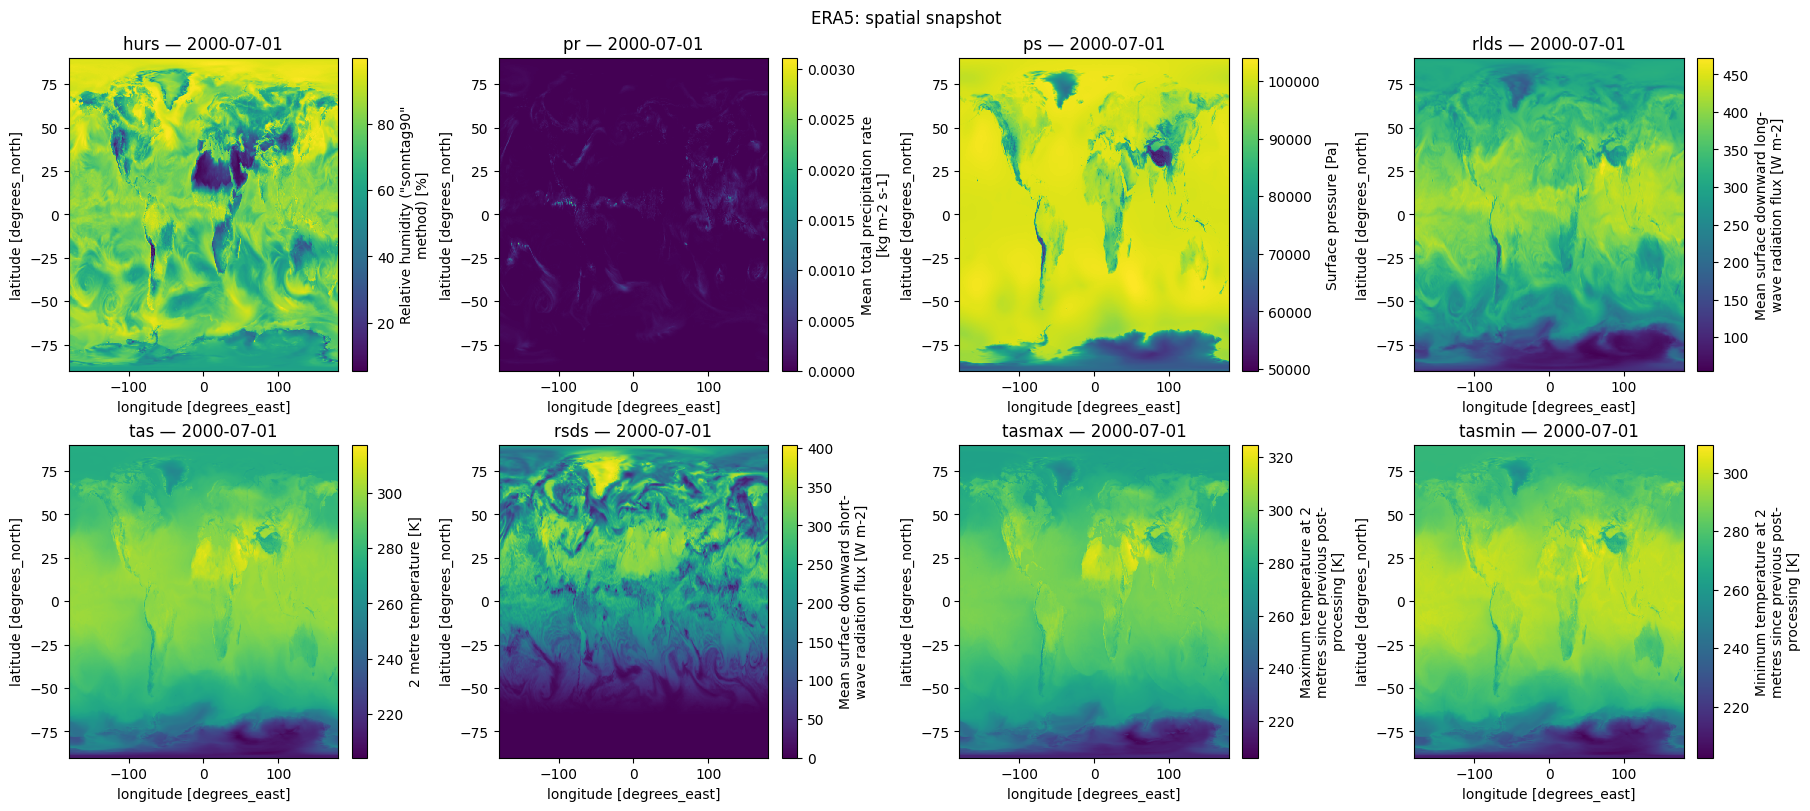

In [4]:
date = "2000-07-01"
variables = list(ds.data_vars)
fig, axes = plt.subplots(2, len(variables) // 2, figsize=(18, 8), constrained_layout=True)

for ax, var in zip(axes.ravel(), variables):
    ds[var].sel(time=date).plot(ax=ax, cmap="viridis")
    ax.set_title(f"{var} — {date}")
fig.suptitle("ERA5: spatial snapshot");

### 1.2 Time coverage check

In [5]:
expected = pd.date_range(ds.time.values[0], ds.time.values[-1], freq="D")
actual = pd.DatetimeIndex(ds.time.values)
print(f"Expected days: {len(expected)}, actual: {len(actual)}")
print(f"Missing days: {len(expected.difference(actual))}")
print(f"Duplicate days: {actual.duplicated().sum()}")
print(f"Monotonic increasing: {actual.is_monotonic_increasing}")

Expected days: 23741, actual: 23741
Missing days: 0
Duplicate days: 0
Monotonic increasing: True


### 1.3 Physical-constraint checks (one-year subset)

`src/srm/qaqc.py` provides `check_physical_constraints`, which flags negative/outlandish
precipitation, outlandish temperatures, and non-monotonic `tasmin <= tas <= tasmax`
relationships. We run it on a single year to keep the compute small.

In [6]:
era5_subset = ds.sel(time="2010").compute()
qaqc.check_physical_constraints(era5_subset)

Number of negative precipitation values: 0
Number of outlandishly high precipitation values: 0
Number of outlandishly high tas values: 0
Number of outlandishly high tasmax values: 0
Number of outlandishly high tasmin values: 0
Number of outlandishly low tas values: 0
Number of outlandishly low tasmax values: 0
Number of outlandishly low tasmin values: 0
Number of times tasmin exceeds tas: 5098890
Number of times tas exceeds tasmax: 3712149
Number of times tasmin exceeds tasmax: 0


## 2. CESM2-WACCM Store

`cesm2_waccm.py` produces a single unified icechunk store at
`UNIFIED_PREFIX = input/tensor/cesm2-waccm.icechunk`, organized as **zarr groups** keyed by
scenario (`SCENARIO_TO_GROUP`):

| Scenario | Group |
|---|---|
| `historical` | `historical` |
| `pangeo-historical` | `historical` (merged in) |
| `ssp245` | `ssp245` |
| `G6-1.5K` | `g6_1p5k` |

Each scenario's raw NetCDF files are virtualized (`virtualizarr` + `HDFParser`) into
zarr-compatible references, materialized, calendar-converted to `proleptic_gregorian`
(`to_proleptic_gregorian` : handles `noleap` and `360_day` source calendars via
interpolation), and written with an `ensemble_member` dimension.

### The `historical` group: a two-source merge

The `historical` group combines two independent sources with different ensemble-member
identifiers and time spans:

- **ESGF member `'001'`** — all 6 variables (`tas`, `tasmax`, `tasmin`, `pr`, `rsds`, `hurs`),
  1978–2015.
- **Pangeo `pangeo-historical` members `r1i1p1f1`, `r2i1p1f1`, `r3i1p1f1`** — only
  `PANGEO_VARIABLES = ["tas", "rsds", "hurs", "pr"]` (no `tasmax`/`tasmin` — these don't exist
  for these members in any public archive), 1850–2015.

Because the two sources have different `ensemble_member` and `time` coordinates, appending
the Pangeo data directly with `to_icechunk(mode="a")` raised
`ValueError: variable 'tas' already exists with different dimension sizes`.
`merge_pangeo_into_historical` resolves this by **reindexing both datasets onto the union of
`ensemble_member` and `time` coordinates** and combining with `combine_first`, then
rewriting the group with `write_mode="w"`. The practical consequence (visible below):
`tasmax`/`tasmin` are `NaN` for the three Pangeo members, and all variables are `NaN` for
`'001'` outside its 1978–2015 span.

The `ssp245` and `g6_1p5k` groups follow the simpler single-source path
(`process_cesm_var` → `process_cesm_pipeline`), with one `ensemble_member` per ESGF variant
label (`'001'`–`'010'`).

In [7]:
storage = icechunk.s3_storage(bucket="carbonplan-srm", prefix="input/tensor/cesm2-waccm.icechunk")
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")

In [8]:
dt = xr.open_datatree(session.store, engine="zarr", chunks="auto")
dt

<xarray.DataTree>
Group: /
├── Group: /g6_1p5k
│       Dimensions:          (ensemble_member: 3, time: 18264, lat: 192, lon: 288)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 24B '001' '002' '003'
│         * time             (time) datetime64[ns] 146kB 2035-01-01 ... 2085-01-01
│         * lat              (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
│         * lon              (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
│       Data variables:
│           hurs             (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           pr               (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           tasmin           (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│       Attributes: (12/15)
│           Conventions:                CF-1.0
│           source:                     CAM
│           case:                       b.e21.BW.f09_g17.SSP245-G6-SAI-1p5.001
│           logname:                    walkerl
│           host:                       derecho4
│           initial_file:               b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WA...
│           ...                         ...
│           _source_manifest:           {"source_url": "s3://carbonplan-srm/input/ten...
│           scenario:                   G6-1.5K
│           model:                      CESM2-WACCM
│           experiment_lineage:         unknown_parent -> G6-1.5K
│           processing_steps:           time_drop_duplicates, lon_to_180, lat_lon_sor...
│           ensemble_derivation_logic:  Ensemble member derived from url or variant_l...
├── Group: /historical
│       Dimensions:          (ensemble_member: 4, time: 60281, lat: 192, lon: 288)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 32B '001' ... 'r3i1p1f1'
│         * time             (time) datetime64[ns] 482kB 1850-01-01 ... 2015-01-16
│         * lat              (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
│         * lon              (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
│       Data variables:
│           tasmin           (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           hurs             (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           pr               (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│       Attributes: (12/49)
│           Conventions:                CF-1.7 CMIP-6.2
│           source:                     CESM2 (2017): atmosphere: CAM6 (0.9x1.25 fini...
│           case:                       b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WA...
│           logname:                    tilmes
│           host:                       cheyenne2
│           initial_file:               b.e21.BWHIST.f09_g17.CMIP6-historical-WACCM.0...
│           ...                         ...
│           source_type:                AOGCM BG

### 2.1 Group summary

In [9]:
summarize_groups(dt)

,ensemble_members,n_time,time_start,time_end,lat x lon,variables
group,,,,,,
g6_1p5k,3,18264,2035-01-01,2085-01-01,192 x 288,"hurs, pr, rsds, tas, tasmax, tasmin"
historical,4,60281,1850-01-01,2015-01-16,192 x 288,"hurs, pr, rsds, tas, tasmax, tasmin"
ssp245,10,31412,2015-01-01,2101-01-01,192 x 288,"hurs, pr, rsds, tas, tasmax, tasmin"


### 2.2 `historical` group: merge coverage check

For each variable, plot the fraction of NaN years per ensemble member at a single grid
point. We expect `'001'` to be NaN outside 1978–2015 for every variable, and the three
Pangeo members (`r*i1p1f1`) to be NaN for `tasmax`/`tasmin` everywhere and for the other
variables outside 1850–2015.

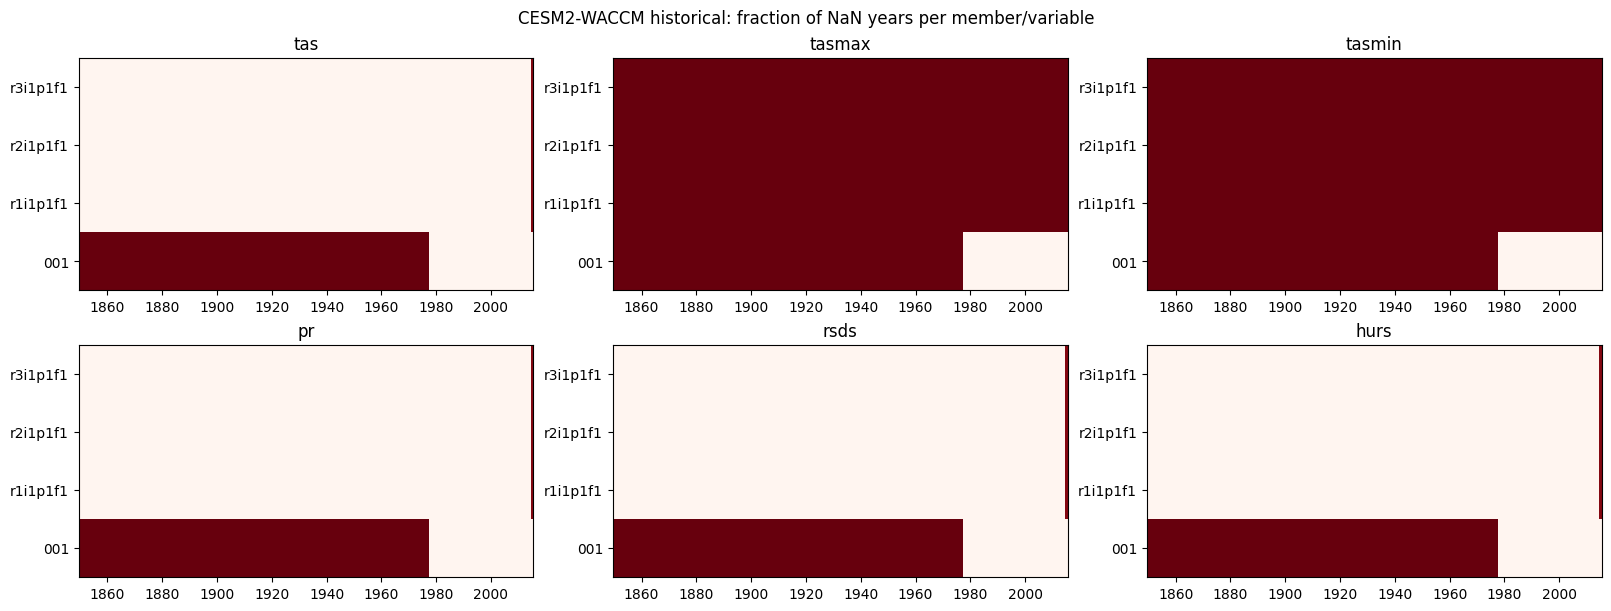

In [10]:
hist_cesm = dt["historical"].to_dataset()

fig, axes = plt.subplots(2, 3, figsize=(16, 6), constrained_layout=True)
for ax, var in zip(axes.ravel(), ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]):
    mask = point_missingness(hist_cesm, var)
    frac = mask.resample(time="YS").mean()
    im = ax.pcolormesh(
        frac.time,
        np.arange(frac.sizes["ensemble_member"]),
        frac.values,
        cmap="Reds",
        vmin=0,
        vmax=1,
    )
    ax.set_yticks(np.arange(frac.sizes["ensemble_member"]))
    ax.set_yticklabels(frac.ensemble_member.values)
    ax.set_title(var)
fig.suptitle("CESM2-WACCM historical: fraction of NaN years per member/variable");

### 2.3 Spatial comparison: ESGF `'001'` vs Pangeo `r1i1p1f1`

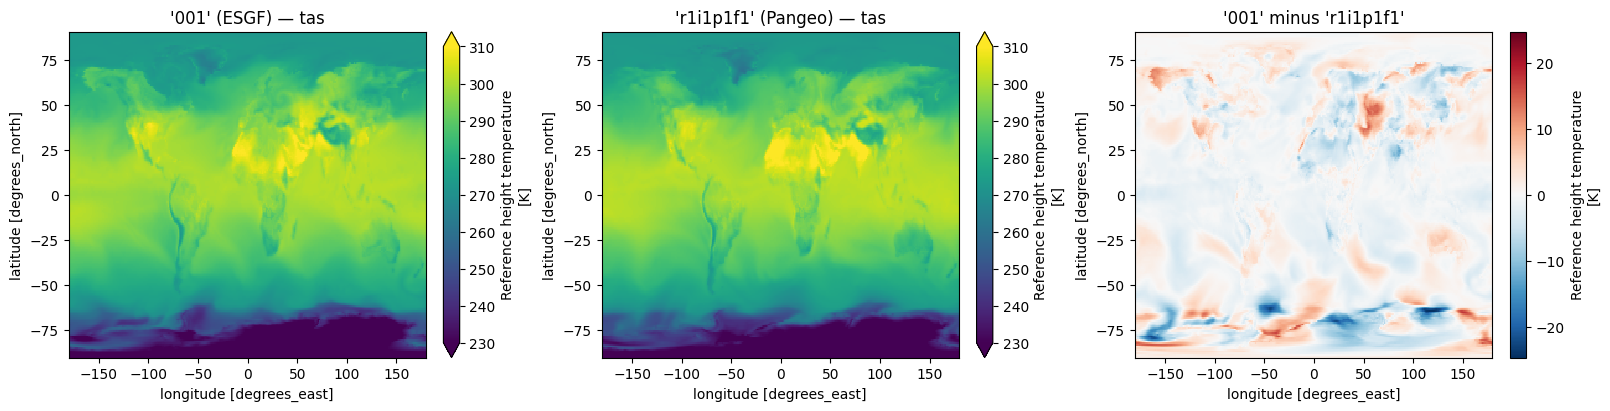

In [11]:
date = "2000-07-01"
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

da_001 = hist_cesm["tas"].sel(ensemble_member="001", time=date)
da_r1 = hist_cesm["tas"].sel(ensemble_member="r1i1p1f1", time=date)

da_001.plot(ax=axes[0], vmin=230, vmax=310)
axes[0].set_title("'001' (ESGF) — tas")

da_r1.plot(ax=axes[1], vmin=230, vmax=310)
axes[1].set_title("'r1i1p1f1' (Pangeo) — tas")

(da_001 - da_r1).plot(ax=axes[2], cmap="RdBu_r")
axes[2].set_title("'001' minus 'r1i1p1f1'");

### 2.4 Ensemble-mean time series across the merge

A continuous annual-mean time series at a single grid point should show all four members
tracking each other reasonably well, with `'001'` only appearing from 1978 onward.

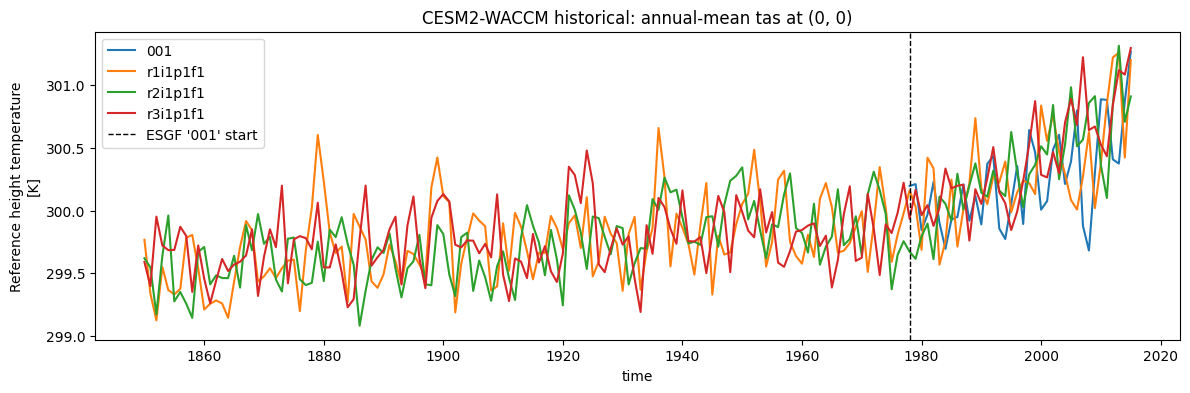

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
for member in hist_cesm.ensemble_member.values:
    da = (
        hist_cesm["tas"]
        .sel(ensemble_member=member)
        .sel(lat=0, lon=0, method="nearest")
        .resample(time="YS")
        .mean()
        .compute()
    )
    da.plot(ax=ax, label=str(member))
ax.axvline(pd.Timestamp("1978-01-01"), color="k", ls="--", lw=1, label="ESGF '001' start")
ax.legend()
ax.set_title("CESM2-WACCM historical: annual-mean tas at (0, 0)");

### 2.5 `ssp245` group: completeness check

`ssp245` was still being populated when this notebook was first written (only `tas` was
present). All 6 variables and all 10 members have since landed — confirm completeness and
check for residual structural NaNs.

In [13]:
ssp_cesm = dt["ssp245"].to_dataset()
print("Variables present in ssp245 group:", sorted(ssp_cesm.data_vars))
print("Members:", list(ssp_cesm.ensemble_member.values))
print(f"Time range: {str(ssp_cesm.time.values[0])[:10]} -> {str(ssp_cesm.time.values[-1])[:10]}")

for var in sorted(ssp_cesm.data_vars):
    mask = point_missingness(ssp_cesm, var)
    print(f"{var}: NaN fraction at (0, 0) = {float(mask.mean()):.4%}")

Variables present in ssp245 group: ['hurs', 'pr', 'rsds', 'tas', 'tasmax', 'tasmin']
Members: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']
Time range: 2015-01-01 -> 2101-01-01
hurs: NaN fraction at (0, 0) = 18.0221%
pr: NaN fraction at (0, 0) = 18.0221%
rsds: NaN fraction at (0, 0) = 18.0221%
tas: NaN fraction at (0, 0) = 18.0221%
tasmax: NaN fraction at (0, 0) = 68.0221%
tasmin: NaN fraction at (0, 0) = 68.0221%


## 3. MIROC-ES2H Store

`miroc.py` mirrors the CESM2-WACCM structure: a unified store at
`UNIFIED_PREFIX = input/tensor/miroc-es2h.icechunk` with groups `historical`, `ssp245`,
`g6_1p5k` (`SCENARIO_TO_GROUP`). All 6 `MIROC_VARIABLES`
(`hurs`, `pr`, `rsds`, `tas`, `tasmax`, `tasmin`) are processed for every scenario.

Two notable pipeline behaviors:

- **`hurs` units** : `CMORIZE_HURS` converts `hurs` from a 0–1 fraction to percent for
  scenarios where it isn't already in percent (`historical` is left as-is; others are
  multiplied by 100 via `cmorize_miroc`).
- **`ssp245` gap-stitching** : GeoMIP baseline runs (10 members, `r01`–`r10`) start in 2020,
  leaving a 2015–2019 gap relative to the historical record. `_load_ssp245_with_gap_fill`
  bridges this gap using `esgf-ssp245` (members `r1i1p4f2`, `r2i1p4f2`, `r3i1p4f2`,
  2015–2019), relabelling each ESGF bridge member to the GeoMIP member it feeds via
  `_SSP245_ESGF_MEMBER`, and `xr.concat`-ing `[gap_ds, geomip]` along `time`. The result is a
  continuous 2015–2100 `ssp245` group with **no structural gap** — unlike CESM2-WACCM's
  `historical` group, there should be no merge-induced NaNs here, which is worth confirming
  below.

`historical` (3 members, `r1i1p4f2`/`r2i1p4f2`/`r3i1p4f2`) and `g6_1p5k` (10 members,
`r01`–`r10`) follow the simpler single-source path.

In [14]:
storage = icechunk.s3_storage(bucket="carbonplan-srm", prefix="input/tensor/miroc-es2h.icechunk")
repo_miroc = icechunk.Repository.open(storage)
session_miroc = repo_miroc.readonly_session("main")
dt_miroc = xr.open_datatree(session_miroc.store, engine="zarr", chunks="auto")
dt_miroc

<xarray.DataTree>
Group: /
├── Group: /g6_1p5k
│       Dimensions:          (ensemble_member: 10, time: 18263, lat: 128, lon: 256)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 80B 'r01' 'r02' ... 'r09' 'r10'
│         * time             (time) datetime64[ns] 146kB 2035-01-01T12:00:00 ... 2084...
│         * lat              (lat) float64 1kB -88.93 -87.54 -86.14 ... 87.54 88.93
│         * lon              (lon) float64 2kB -180.0 -178.6 -177.2 ... 177.2 178.6
│       Data variables:
│           tasmin           (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           hurs             (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           pr               (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│       Attributes: (12/14)
│           Conventions:                CF-1.8
│           title:                      MIROC-ES2H GeoMIP EXPERIMENT DATA
│           model_id:                   MIROC-ES2H
│           source:                     MIROC-ES2H (2023): \naerosol: SPRINTARS6.0\na...
│           institute_id:               MIROC
│           instituion:                 JAMSTEC (Japan Agency for Marine-Earth Scienc...
│           ...                         ...
│           references:                 MIROC-ES2H : Kawamiya, M., Hajima, T., Tachii...
│           experiment_id:              GeoMIP
│           license:                    GeoMIP simulation data produced by MIROC-team...
│           scenario:                   G6-1.5K
│           model:                      MIROC-ES2H
│           ensemble_derivation_logic:  Raw filename suffix: url.split('.nc')[0].spli...
├── Group: /historical
│       Dimensions:          (ensemble_member: 3, time: 60265, lat: 128, lon: 256)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 24B 'r1i1p4f2' ... 'r3i1p4f2'
│         * time             (time) datetime64[ns] 482kB 1850-01-01T12:00:00 ... 2014...
│         * lat              (lat) float64 1kB -88.93 -87.54 -86.14 ... 87.54 88.93
│         * lon              (lon) float64 2kB -180.0 -178.6 -177.2 ... 177.2 178.6
│           height           float64 8B ...
│       Data variables:
│           tasmin           (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(3, 330, 128, 256), meta=np.ndarray>
│           pr               (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(3, 330, 128, 256), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(3, 330, 128, 256), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(3, 330, 128, 256), meta=np.ndarray>
│           hurs             (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(3, 330, 128, 256), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(3, 330, 128, 256), meta=np.ndarray>
│       Attributes: (12/48)
│           Conventions:                CF-1.8
│           activity_id:                CMIP
│           branch_method:              standard
│           branch_time_in_child:       0.0
│           branch_time_in_parent:      0.0
│           creation_date:              2023-08-09T12:36:31Z
│           ...                         ...
│           cmor_version:               3.3.2
│           tracking_id:                hdl:21.1

### 3.1 Group summary

In [15]:
summarize_groups(dt_miroc)

,ensemble_members,n_time,time_start,time_end,lat x lon,variables
group,,,,,,
g6_1p5k,10,18263,2035-01-01,2084-12-31,128 x 256,"hurs, pr, rsds, tas, tasmax, tasmin"
historical,3,60265,1850-01-01,2014-12-31,128 x 256,"hurs, pr, rsds, tas, tasmax, tasmin"
ssp245,10,25568,2015-01-01,2084-12-31,128 x 256,"hurs, pr, rsds, tas, tasmax, tasmin"


### 3.2 `ssp245` stitch boundary: continuity check (2015–2020)

Unlike the CESM2-WACCM `historical` merge, the MIROC `ssp245` gap-fill is a `concat` along
`time` onto disjoint member sets that are then relabelled to align — the result should be
**gap-free**. The heatmap below should show all-zero (white) NaN fraction across the
2015–2020 boundary.

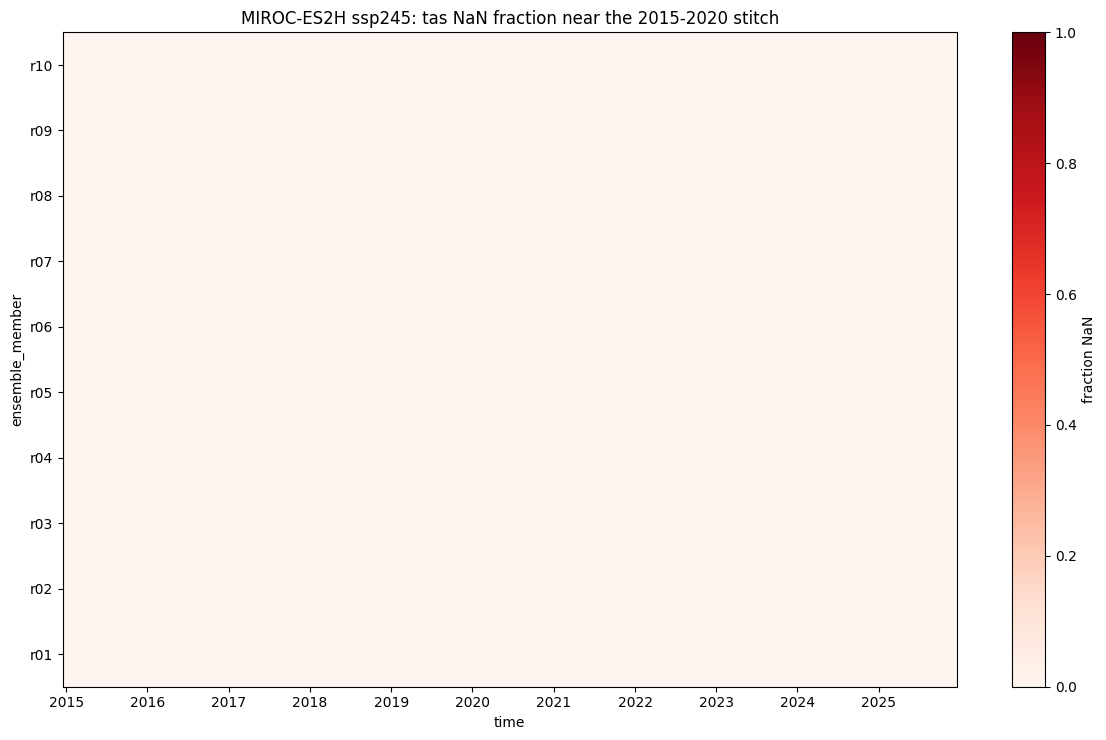

In [16]:
ssp_miroc = dt_miroc["ssp245"].to_dataset()
mask = point_missingness(ssp_miroc, "tas").sel(time=slice("2010", "2025"))
plot_missingness(mask, "MIROC-ES2H ssp245: tas NaN fraction near the 2015-2020 stitch", freq="MS")

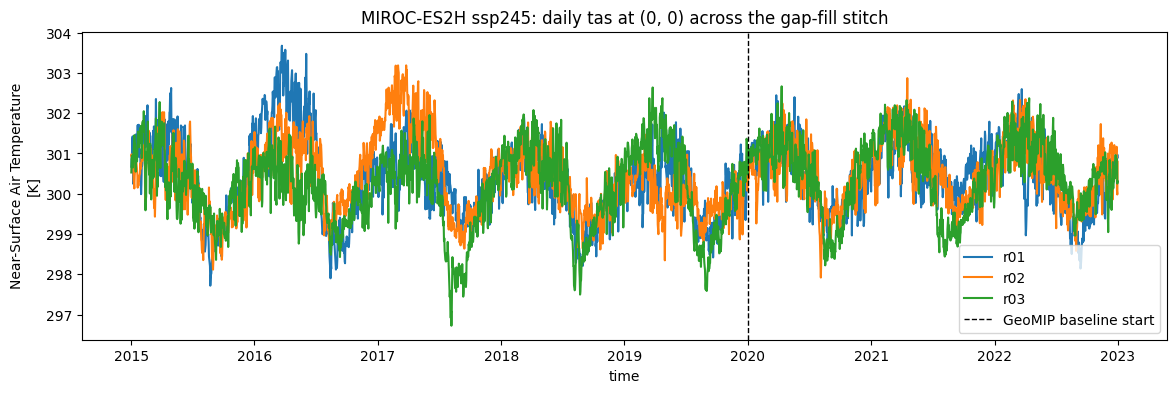

In [17]:
fig, ax = plt.subplots(figsize=(14, 4))
for member in ssp_miroc.ensemble_member.values[:3]:
    da = (
        ssp_miroc["tas"]
        .sel(ensemble_member=member)
        .sel(lat=0, lon=0, method="nearest")
        .sel(time=slice("2014", "2022"))
        .compute()
    )
    da.plot(ax=ax, label=str(member))
ax.axvline(pd.Timestamp("2020-01-01"), color="k", ls="--", lw=1, label="GeoMIP baseline start")
ax.legend()
ax.set_title("MIROC-ES2H ssp245: daily tas at (0, 0) across the gap-fill stitch");

### 3.3 Spatial sanity check

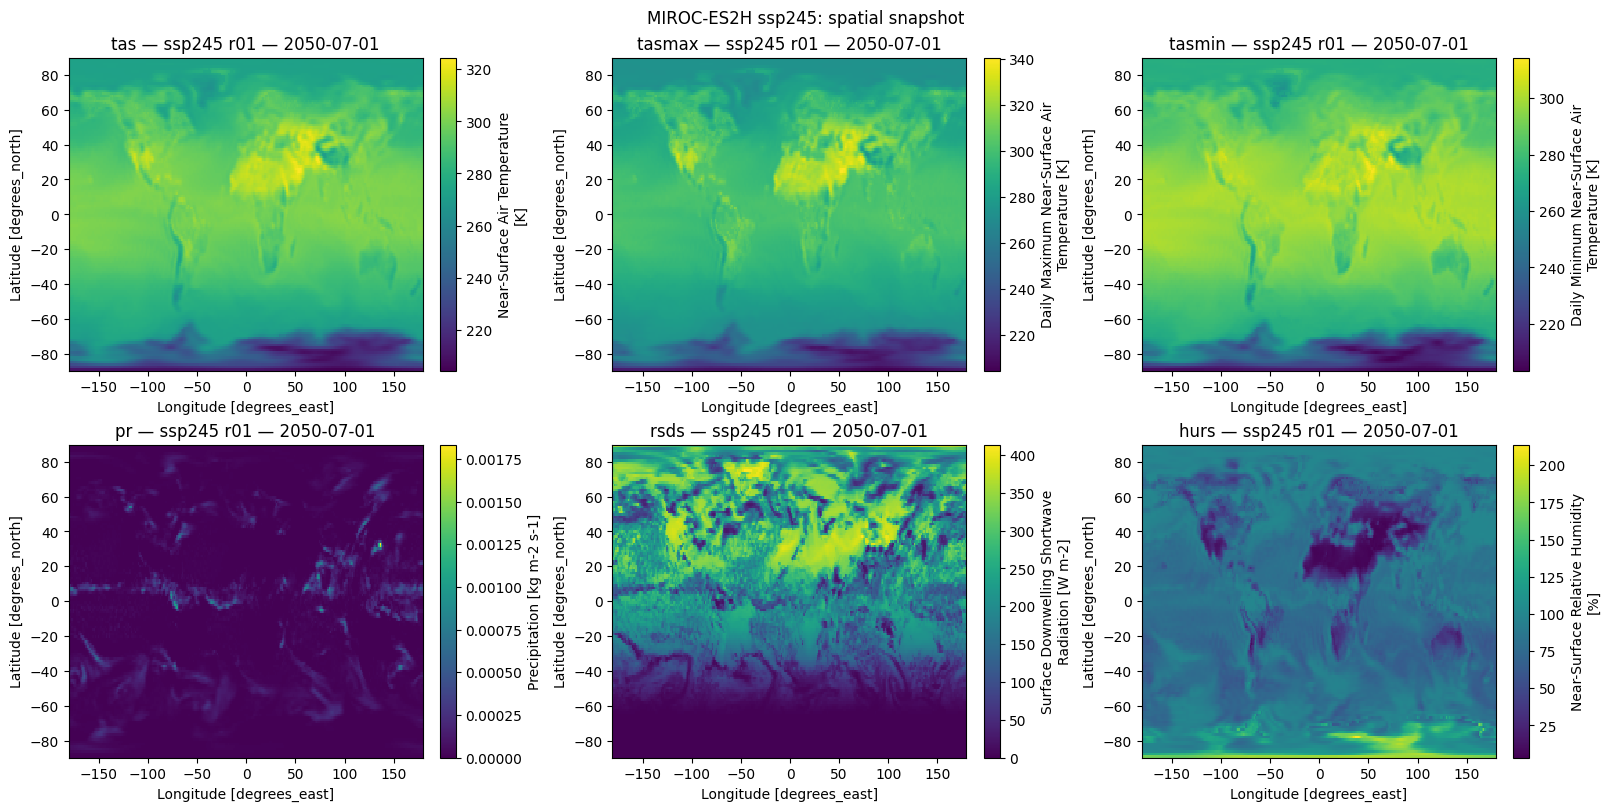

In [18]:
date = "2050-07-01"
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, var in zip(axes.ravel(), ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]):
    ssp_miroc[var].sel(ensemble_member="r01", time=date).plot(ax=ax, cmap="viridis")
    ax.set_title(f"{var} — ssp245 r01 — {date}")
fig.suptitle("MIROC-ES2H ssp245: spatial snapshot");

## 4. Cross-GCM comparison

CESM2-WACCM (`192 x 288`), MIROC-ES2H (`128 x 256`), and ERA5 (`721 x 1440`) are on
different native grids — that's expected here, since regridding to a common grid is the
job of `prepare_observations` in the BCSD pipeline, not these ETL stores. This section is
just a visual gut-check that the two GCMs' `historical` `tas` fields are in the right
ballpark and show the same broad spatial pattern for an overlapping date.

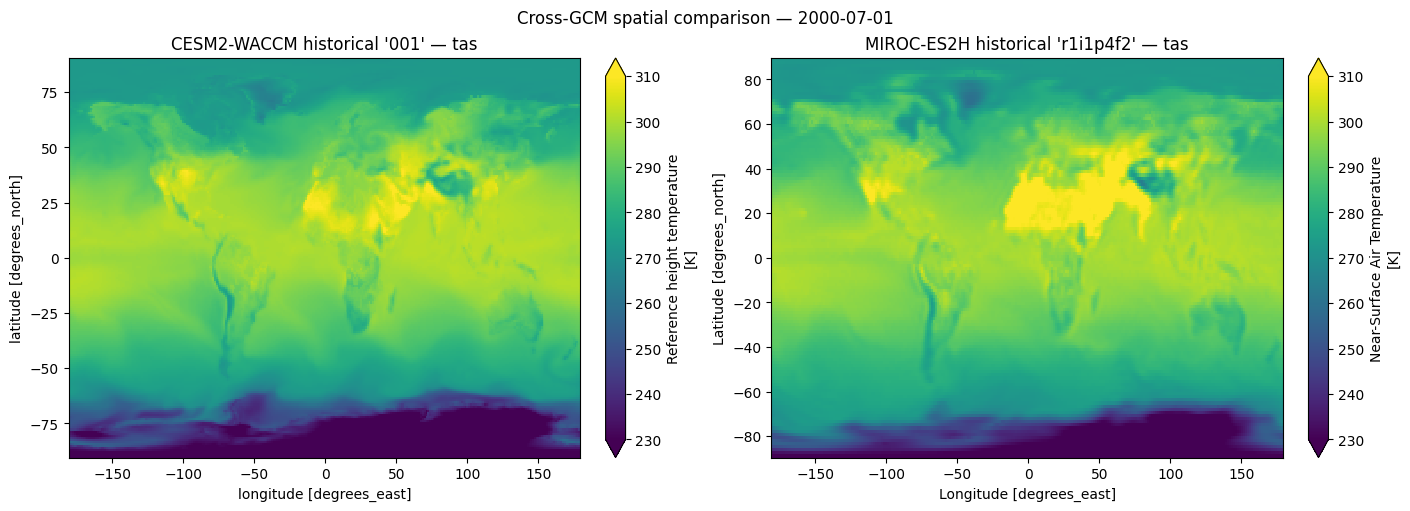

In [19]:
date = "2000-07-01"
hist_miroc = dt_miroc["historical"].to_dataset()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
hist_cesm["tas"].sel(ensemble_member="001", time=date).plot(ax=axes[0], vmin=230, vmax=310)
axes[0].set_title("CESM2-WACCM historical '001' — tas")

hist_miroc["tas"].sel(ensemble_member="r1i1p4f2", time=date).plot(ax=axes[1], vmin=230, vmax=310)
axes[1].set_title("MIROC-ES2H historical 'r1i1p4f2' — tas")

fig.suptitle(f"Cross-GCM spatial comparison — {date}");

## 5. Summary checklist

Use this checklist while reviewing the outputs above:

- [ ] **ERA5**: time axis is gap-free and monotonic (1950-01-01 → 2014-12-31, no
  duplicates).
- [ ] **ERA5**: spatial fields look physically plausible (no obvious striping/blank
  regions).
- [ ] **ERA5**: `qaqc.check_physical_constraints` reports zero violations for the 2010
  subset.
- [ ] **CESM2-WACCM `historical`**: NaN coverage matches expectations — `'001'` is NaN
  outside 1978–2015 for all variables; Pangeo members (`r*i1p1f1`) are NaN for
  `tasmax`/`tasmin` everywhere and for `tas`/`pr`/`rsds`/`hurs` outside 1850–2015.
- [ ] **CESM2-WACCM `historical`**: `'001'` vs `'r1i1p1f1'` `tas` fields are spatially
  consistent (similar magnitude/pattern, not identical — different ensemble members).
- [ ] **CESM2-WACCM `ssp245`**: all 6 variables (`hurs`, `pr`, `rsds`, `tas`, `tasmax`,
  `tasmin`) present across all 10 members, 2015–2101, with no structural NaNs.
- [ ] **MIROC-ES2H `ssp245`**: no NaN gap around the 2015–2020 stitch boundary, and the
  `tas` time series is continuous (no jump/discontinuity) across 2020-01-01.
- [ ] **Cross-GCM**: CESM2-WACCM (`192x288`) and MIROC-ES2H (`128x256`) historical `tas`
  fields show the same broad spatial pattern as ERA5 (`721x1440`) for the same date.

### 5.1 Physical-constraint checks (CESM2-WACCM & MIROC-ES2H, one member/year)

In [20]:
print("CESM2-WACCM historical '001', 2000:")
qaqc.check_physical_constraints(hist_cesm.sel(ensemble_member="001", time="2000").compute())

print("\nMIROC-ES2H historical 'r1i1p4f2', 2000:")
qaqc.check_physical_constraints(hist_miroc.sel(ensemble_member="r1i1p4f2", time="2000").compute())

CESM2-WACCM historical '001', 2000:
Number of negative precipitation values: 0
Number of outlandishly high precipitation values: 0
Number of outlandishly high tas values: 0
Number of outlandishly high tasmax values: 0
Number of outlandishly high tasmin values: 0
Number of outlandishly low tas values: 0
Number of outlandishly low tasmax values: 0
Number of outlandishly low tasmin values: 0
Number of times tasmin exceeds tas: 0
Number of times tas exceeds tasmax: 0
Number of times tasmin exceeds tasmax: 0

MIROC-ES2H historical 'r1i1p4f2', 2000:
Number of negative precipitation values: 0
Number of outlandishly high precipitation values: 0
Number of outlandishly high tas values: 0
Number of outlandishly high tasmax values: 429
Number of outlandishly high tasmin values: 0
Number of outlandishly low tas values: 0
Number of outlandishly low tasmax values: 0
Number of outlandishly low tasmin values: 0
Number of times tasmin exceeds tas: 0
Number of times tas exceeds tasmax: 0
Number of times 